In [7]:
from collections import defaultdict


def parse_line_kv_only(line: str):
    result = {}

    for kv in line.split(","):
        if "=" in kv:
            k, v = kv.split("=")
            result[k] = v

    return result


def aggregate_dicts(dicts: list[dict]):
    aggregated = defaultdict(lambda: defaultdict(list))

    for d in dicts:
        key = (d["param"], d["noise_level"], d["n_pts"], d["n_indivs"])

        for k, v in d.items():
            if k not in {"param", "noise_level", "n_pts", "n_indivs"}:
                aggregated[key][k].append(v)

    return dict(aggregated)


import numpy as np
import matplotlib.pyplot as plt


def plot_heatmap_from_aggregated(aggregated, k, save_fname=None):
    # Extract unique noise_levels and n_pts, sorted for consistent ordering
    param = list(aggregated.keys())[0][0]
    noise_levels = sorted(
        set(key[1] for key in aggregated.keys()), key=lambda x: float(x)
    )
    n_pts_values = sorted(
        set(key[2] for key in aggregated.keys()), key=lambda x: float(x), reverse=True
    )
    n_indivs = list(aggregated.keys())[0][0]

    # Initialize heatmap array
    heatmap = np.zeros((len(noise_levels), len(n_pts_values)))

    for i, nl in enumerate(noise_levels):
        for j, np_ in enumerate(n_pts_values):
            key = next(
                iter(k_ for k_ in aggregated if k_[1] == nl and k_[2] == np_), None
            )
            if key and k in aggregated[key]:
                values = [float(x) for x in aggregated[key][k]]
                heatmap[i, j] = np.median(values)
            else:
                heatmap[i, j] = np.nan  # in case some combinations are missing

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.imshow(heatmap, cmap="viridis", aspect="auto")

    # Set labels
    ax.set_xticks(np.arange(len(n_pts_values)))
    ax.set_yticks(np.arange(len(noise_levels)))
    ax.set_xticklabels(n_pts_values)
    ax.set_yticklabels(noise_levels)
    ax.set_xlabel("n_pts")
    ax.set_ylabel("noise_level")
    ax.set_title(f"Median heatmap for '{k}', parameter {param}, {n_indivs} individuals")

    # Annotate each cell
    for i in range(len(noise_levels)):
        for j in range(len(n_pts_values)):
            val = heatmap[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2e}", ha="center", va="center", color="red")

    fig.colorbar(cax, ax=ax, label="Median Value")
    plt.tight_layout()
    plt.show()
    if save_fname:
        fig.savefig(save_fname)

def plot_heatmap_from_aggregated_2(aggregated, k, save_fname=None):
    from itertools import product

    # Extract unique noise_levels and n_pts, sorted for consistent ordering
    param = list(aggregated.keys())[0][0]
    noise_levels = sorted(
        set(key[1] for key in aggregated.keys()), key=lambda x: float(x)
    )
    n_pts_values = sorted(
        set(key[2] for key in aggregated.keys()), key=lambda x: float(x), reverse=True
    )
    n_indivs = sorted(
        set(key[3] for key in aggregated.keys()), key=lambda x: float(x), reverse=True
    )

    # Initialize heatmap array
    heatmap = np.zeros((len(noise_levels), len(n_pts_values) * len(n_indivs)))

    for i, nl in enumerate(noise_levels):
        for j, np_ in enumerate(n_pts_values):
            for m, ni in enumerate(n_indivs):
                key = next(
                    iter(k_ for k_ in aggregated if k_[1] == nl and k_[2] == np_ and k_[3] == ni), None
                )
                if key and k in aggregated[key]:
                    values = [float(x) for x in aggregated[key][k]]
                    heatmap[i, len(n_indivs) * j + m] = np.median(values)
                else:
                    heatmap[i, len(n_indivs) * j + m] = np.nan  # in case some combinations are missing

    # Plotting
    fig, ax = plt.subplots(figsize=(15, 6))
    print(heatmap.shape)
    cax = ax.imshow(heatmap, cmap="viridis", aspect="auto")

    # Set labels
    ax.set_xticks(np.arange(len(n_pts_values) * len(n_indivs)))
    ax.set_yticks(np.arange(len(noise_levels)))
    ax.set_xticklabels([f"{x}" for x in product(n_pts_values, n_indivs)])
    ax.set_yticklabels(noise_levels)
    ax.set_xlabel("(n_pts, n_indivs)")
    ax.set_ylabel("noise_level")
    ax.set_title(f"Median heatmap for '{k}', parameter {param}")

    # Annotate each cell
    for i in range(len(noise_levels)):
        for j in range(len(n_pts_values)):
            for m in range(len(n_indivs)):
                val = heatmap[i, len(n_indivs) * j + m]
                if not np.isnan(val):
                    ax.text(len(n_indivs) * j + m, i, f"{val:.2e}", ha="center", va="center", color="red")

    fig.colorbar(cax, ax=ax, label="Median Value")
    plt.tight_layout()
    plt.show()
    if save_fname:
        fig.savefig(save_fname)

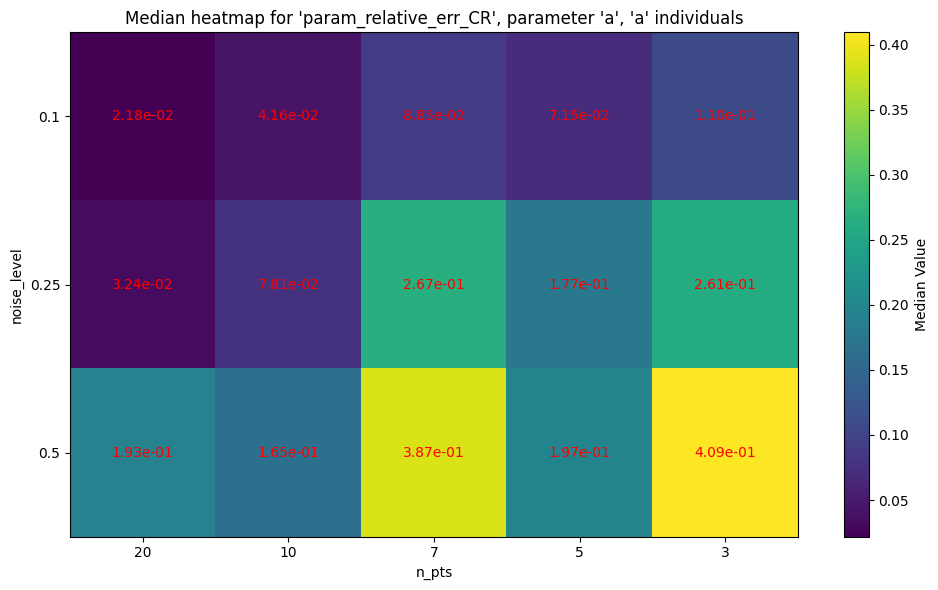

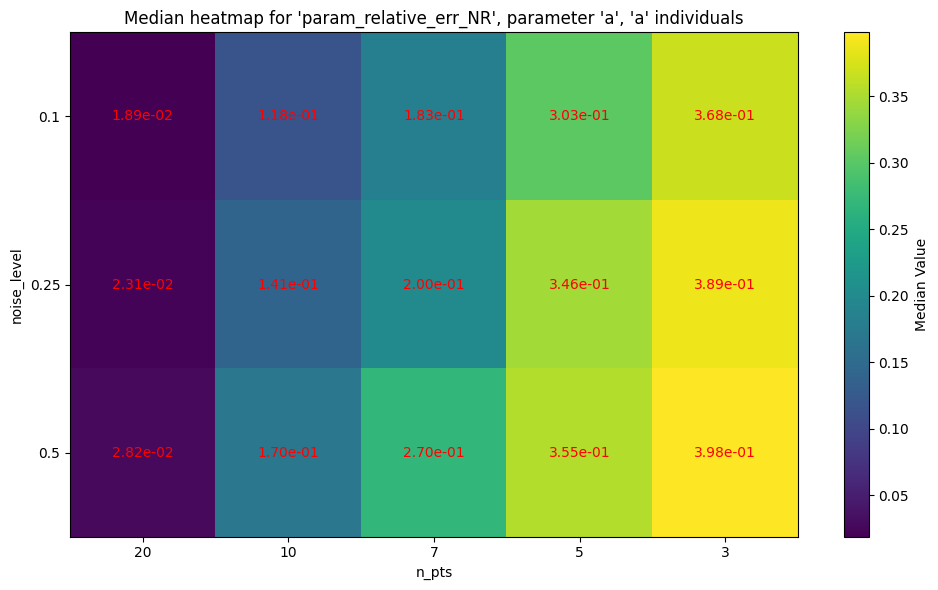

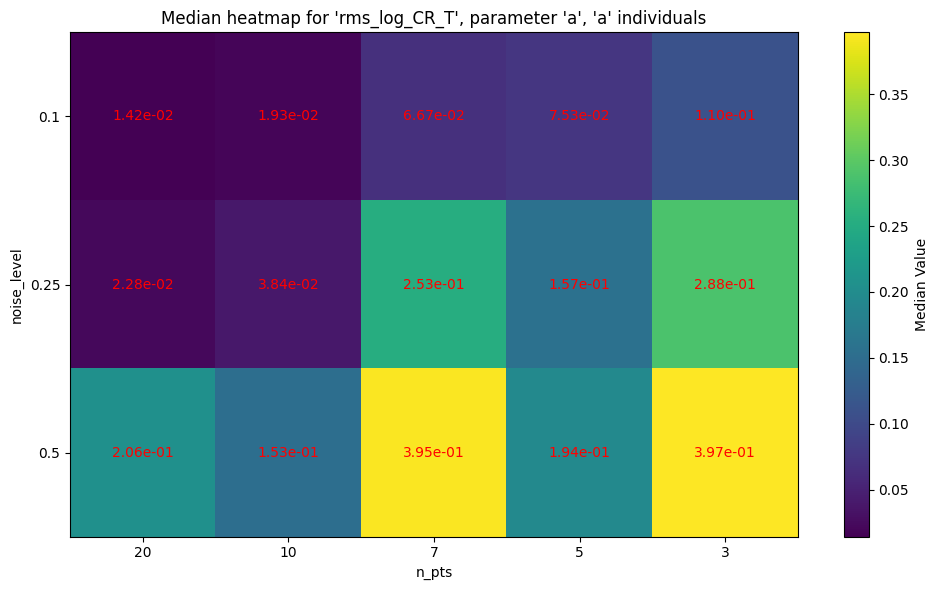

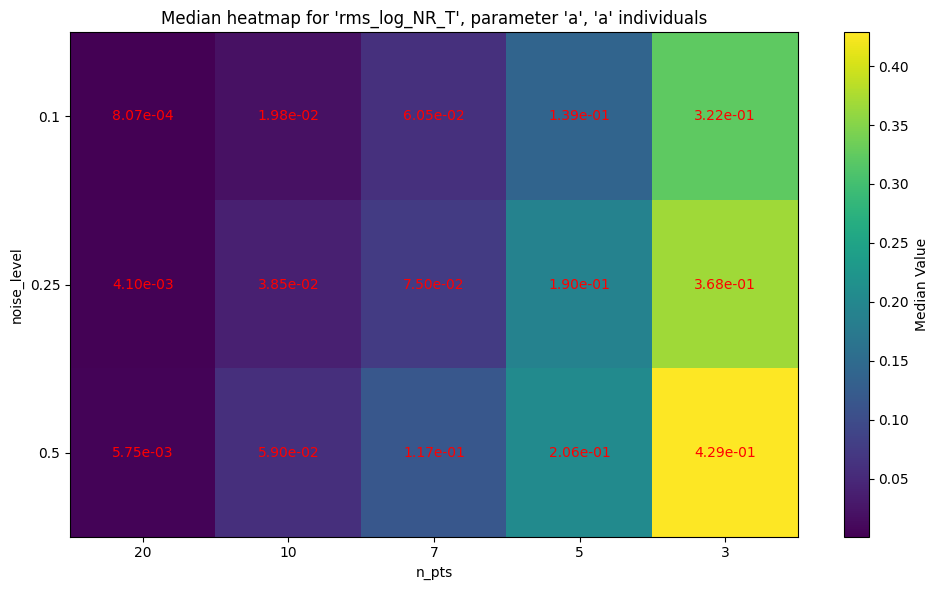

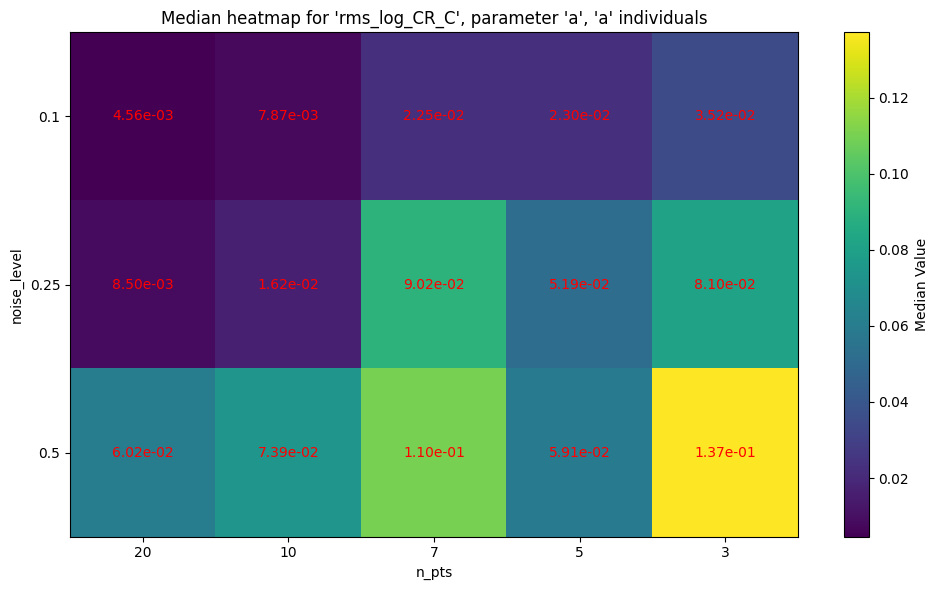

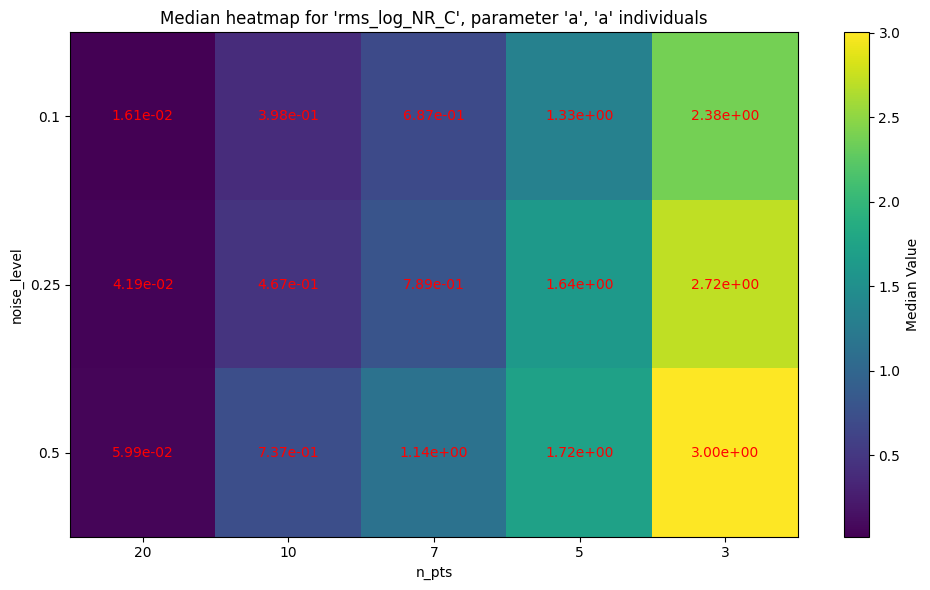

In [9]:
param = "a"

with open(f"results_{param}_v2.txt", "r") as f:
    lines = [line.strip() for line in f.readlines()]
    results = [parse_line_kv_only(line) for line in lines]
    agg = aggregate_dicts(results)

# for key in results[0].keys():
#     if (
#         key not in ["param", "noise_level", "n_pts", "param_seed", "noise_seed", "n_indivs"]
#         and "_M" not in key
#         and "did_converge" not in key
#     ):
#         plot_heatmap_from_aggregated(agg, key, save_fname=f"img/{key}-{param}-n_indivs=10")
for key in [
    "param_relative_err_CR",
    "param_relative_err_NR",
    "rms_log_CR_T",
    "rms_log_NR_T",
    "rms_log_CR_C",
    "rms_log_NR_C",
]:
    plot_heatmap_from_aggregated(agg, key)